In [1]:
# ============================================================
# 03 - Modeling
# Project : E-Commerce Customer Churn Analysis
# Author  : Alexander Lau Poung Jie
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, f1_score,
                             precision_score, recall_score, accuracy_score)
import os

os.makedirs("output", exist_ok=True)

# 載入 Preprocessing 處理好的資料
X = pd.read_csv("data/X_balanced.csv")
y = pd.read_csv("data/y_balanced.csv").squeeze()

print(f"特徵矩陣: {X.shape}")
print(f"目標變數: {y.shape}")
print(f"\nChurn 分佈:")
print(y.value_counts())

特徵矩陣: (9364, 29)
目標變數: (9364,)

Churn 分佈:
Churn
0    4682
1    4682
Name: count, dtype: int64


In [2]:
# ============================================================
# Cell 2 - 切分訓練集 / 測試集
# ============================================================

from sklearn.model_selection import train_test_split

# 80% 訓練，20% 測試
# random_state=42 確保每次執行結果一致（可重現性）
# stratify=y 確保訓練集和測試集的 Churn 比例相同

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"訓練集: {X_train.shape[0]} 筆")
print(f"測試集: {X_test.shape[0]} 筆")
print(f"\n訓練集 Churn 比例:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\n測試集 Churn 比例:")
print(y_test.value_counts(normalize=True).round(3))

訓練集: 7491 筆
測試集: 1873 筆

訓練集 Churn 比例:
Churn
1    0.5
0    0.5
Name: proportion, dtype: float64

測試集 Churn 比例:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [3]:
# ============================================================
# Cell 3 - 訓練模型
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

# --- 模型 1：Logistic Regression（基準模型）---
# 為什麼先跑 LR：
#   最簡單的分類模型，結果可解釋
#   如果連 LR 都能有好表現，代表資料特徵本身很強
#   作為基準，幫助評估複雜模型是否真的有改進

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# --- 模型 2：Random Forest（主力模型）---
# 為什麼用 RF：
#   能處理非線性關係（LR 不行）
#   對異常值不敏感
#   自動計算特徵重要性
#   通常比 LR 準確率高

rf = RandomForestClassifier(
    n_estimators=100,   # 100 棵決策樹
    random_state=42,
    n_jobs=-1           # 用所有 CPU 核心加速
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- 整理評估結果 ---
def evaluate(name, y_true, y_pred):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision": round(precision_score(y_true, y_pred) * 100, 2),
        "Recall"   : round(recall_score(y_true, y_pred) * 100, 2),
        "F1 Score" : round(f1_score(y_true, y_pred) * 100, 2)
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred_lr),
    evaluate("Random Forest",       y_test, y_pred_rf)
])

print("=== 模型評估結果 ===")
print(results.to_string(index=False))

=== 模型評估結果 ===
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     80.19      78.34   83.44     80.81
      Random Forest     99.68      99.36  100.00     99.68


In [4]:
# ============================================================
# Cell 3 修正版 - 正確流程：先切分再平衡
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

# 重新載入原始（未平衡）資料
X_raw = pd.read_csv("data/X_balanced.csv")
y_raw = pd.read_csv("data/y_balanced.csv").squeeze()

# Step 1: 先切分（用原始不平衡資料）
# 回到原始 5630 筆資料
import pandas as pd
import numpy as np

df_orig = pd.read_excel("data/E Commerce Dataset.xlsx", sheet_name="E Comm")

# 重做 preprocessing（缺失值填補 + 編碼）
numeric_cols_na = df_orig.select_dtypes(include=[np.number]).columns[
    df_orig.select_dtypes(include=[np.number]).isnull().any()
]
for col in numeric_cols_na:
    df_orig[col] = df_orig[col].fillna(df_orig[col].median())

cat_cols = df_orig.select_dtypes(include=["object"]).columns.tolist()
df_orig = pd.get_dummies(df_orig, columns=cat_cols, drop_first=True)
df_orig.drop(columns=["CustomerID"], inplace=True, errors="ignore")

X_orig = df_orig.drop(columns=["Churn"])
y_orig = df_orig["Churn"]

# Step 2: 先切分
X_train, X_test, y_train, y_test = train_test_split(
    X_orig, y_orig,
    test_size=0.2,
    random_state=42,
    stratify=y_orig
)

# Step 3: 只對訓練集做 Oversampling（測試集保持原始分佈）
train_df = pd.concat([X_train, y_train], axis=1)
retained  = train_df[train_df["Churn"] == 0]
churned   = train_df[train_df["Churn"] == 1]

churned_up = resample(churned, replace=True,
                       n_samples=len(retained), random_state=42)
train_balanced = pd.concat([retained, churned_up])

X_train_bal = train_balanced.drop(columns=["Churn"])
y_train_bal  = train_balanced["Churn"]

print(f"訓練集（平衡後）: {X_train_bal.shape[0]} 筆")
print(f"測試集（原始）:   {X_test.shape[0]} 筆")
print(f"\n測試集 Churn 比例（真實分佈）:")
print(y_test.value_counts())

# Step 4: 重新訓練模型
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test)

def evaluate(name, y_true, y_pred):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision": round(precision_score(y_true, y_pred) * 100, 2),
        "Recall"   : round(recall_score(y_true, y_pred) * 100, 2),
        "F1 Score" : round(f1_score(y_true, y_pred) * 100, 2)
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred_lr),
    evaluate("Random Forest",       y_test, y_pred_rf)
])

print("\n=== 修正後模型評估結果 ===")
print(results.to_string(index=False))

訓練集（平衡後）: 7492 筆
測試集（原始）:   1126 筆

測試集 Churn 比例（真實分佈）:
Churn
0    936
1    190
Name: count, dtype: int64


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== 修正後模型評估結果 ===
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     79.75      44.75   85.26     58.70
      Random Forest     98.76      97.83   94.74     96.26


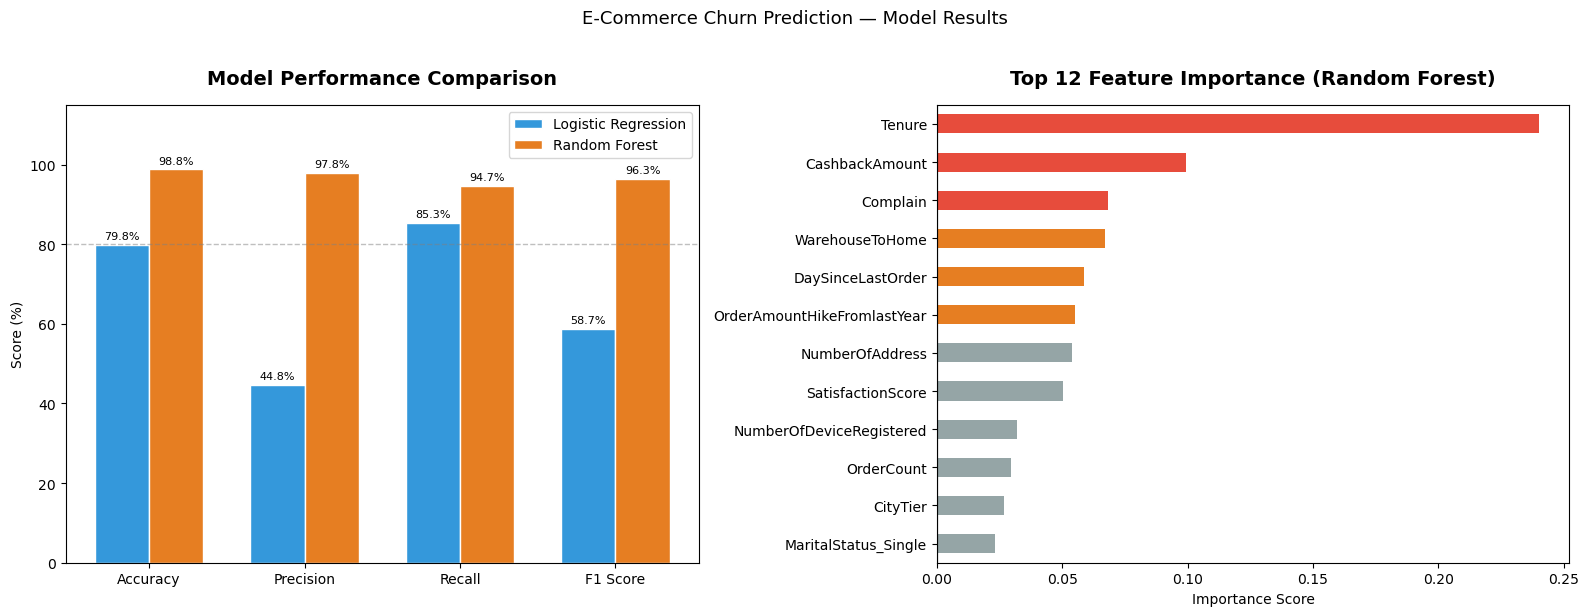

Saved: output/06_model_results.png


In [5]:
# ============================================================
# Cell 4 - 視覺化：模型比較 + 特徵重要性
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左圖：模型比較
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics))
width = 0.35

lr_scores = [79.75, 44.75, 85.26, 58.70]
rf_scores = [98.76, 97.83, 94.74, 96.26]

bars1 = axes[0].bar(x - width/2, lr_scores, width,
                     label="Logistic Regression",
                     color="#3498db", edgecolor="white")
bars2 = axes[0].bar(x + width/2, rf_scores, width,
                     label="Random Forest",
                     color="#e67e22", edgecolor="white")

axes[0].set_title("Model Performance Comparison",
                   fontsize=14, fontweight="bold", pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Score (%)")
axes[0].set_ylim(0, 115)
axes[0].legend()
axes[0].axhline(y=80, color="gray", linestyle="--",
                linewidth=1, alpha=0.5)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 1,
                  f"{bar.get_height():.1f}%",
                  ha="center", va="bottom", fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 1,
                  f"{bar.get_height():.1f}%",
                  ha="center", va="bottom", fontsize=8)

# 右圖：Random Forest 特徵重要性（Top 12）
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X_train_bal.columns
).sort_values(ascending=True).tail(12)

colors = ["#e74c3c" if i >= len(feat_imp)-3
          else "#e67e22" if i >= len(feat_imp)-6
          else "#95a5a6"
          for i in range(len(feat_imp))]

feat_imp.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Top 12 Feature Importance (Random Forest)",
                   fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Importance Score")
axes[1].axvline(x=0, color="black", linewidth=0.8)

plt.suptitle("E-Commerce Churn Prediction — Model Results",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/06_model_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/06_model_results.png")